In [19]:
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- CONFIGURATION ---
DATASET_URL = "https://raw.githubusercontent.com/gizayceylan/FakeNews/main/Datasets/fakeddit_small_2_way.csv"
SAMPLE_SIZE = 200  # Increased to 200 for a better stat sig
MODEL_NAME = "yaoyinnan/roberta-fakeddit"

# --- 1. SETUP TOOLS ---
print("--- [Setup] Loading Forensic Tools... ---")

# Tool A: Specialized RoBERTa (The "Expert" Model)
# We load the model directly to get access to the label mapping (id2label)
print(f"Loading Specialized Model: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Extract the mapping (0 -> Fake, 1 -> Real) directly from the model config
# This prevents the "50% accuracy" bug by not guessing strings.
label_map = model.config.id2label
print(f"DEBUG: Model Label Mapping found: {label_map}")

# Tool B: VADER Sentiment
print("Loading VADER...")
analyzer = SentimentIntensityAnalyzer()

# Tool C: Spacy Entities
print("Loading Spacy...")
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading Spacy model...")
    import os
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

print("--- [Setup] Complete ---")



--- [Setup] Loading Forensic Tools... ---
Loading Specialized Model: yaoyinnan/roberta-fakeddit...


Loading weights: 100%|██| 201/201 [00:00<00:00, 394.58it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: yaoyinnan/roberta-fakeddit
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DEBUG: Model Label Mapping found: {0: 'Fake', 1: 'Real'}
Loading VADER...
Loading Spacy...
--- [Setup] Complete ---


In [21]:
# --- 2. THE INTELLIGENT AGENT LOGIC ---

def run_expert_agent(headline):
    """
    Multi-step reasoning agent:
    1. Check Classifier (Primary Signal)
    2. Extract Entities (Context Signal)
    3. Apply 'Vagueness Penalty' if uncertain
    """
    
    # -- Step 1: RoBERTa Prediction --
    res = classifier(headline)[0]
    raw_label = res['label']
    score = res['score']
    
    # Normalize Label to 0 (Fake) or 1 (Real)
    # The model usually outputs 'LABEL_0' (Fake) or 'LABEL_1' (Real)
    if '1' in raw_label or 'real' in raw_label.lower():
        pred_class = 1
    else:
        pred_class = 0

    # -- Step 2: Entity Extraction --
    doc = nlp(headline)
    entities = [ent.text for ent in doc.ents]
    has_entities = len(entities) > 0
    
    # -- Step 3: Sentiment Analysis --
    vs = analyzer.polarity_scores(headline)
    compound_score = vs['compound']

    # -- Step 4: The "Agentic" Reasoning --
    # Start with the model's prediction
    final_decision = pred_class
    
    # HEURISTIC 1: The "Vagueness Penalty"
    # If the model is not super confident (< 0.85) AND no entities are named,
    # it's likely a vague clickbait title (e.g., "You won't believe this...").
    # Real news usually mentions WHO or WHERE.
    if score < 0.85 and not has_entities:
        # If it was predicted Real (1), flip it to Fake (0)
        # Because real news rarely has NO entities.
        if final_decision == 1:
            final_decision = 0
            
    # HEURISTIC 2: The "Sentiment Check" (Optional Override)
    # If the model is very uncertain (approx 0.5 - 0.6), let Sentiment decide?
    # (Leaving this disabled for now as RoBERTa is usually robust, but logic is here)
    
    return final_decision, score, entities



In [23]:
# --- 3. RUN EXPERIMENT ---
print(f"\n--- [Experiment] Running on {SAMPLE_SIZE} samples ---")

# Load & Clean Data
df = pd.read_csv(DATASET_URL)
# Filter for 2-way labels (0 vs 1)
df = df[df['2_way_label'].isin([0, 1])]
# Drop empty titles
df = df.dropna(subset=['clean_title'])

# Create a balanced dataset
df_fake = df[df['2_way_label'] == 0].sample(SAMPLE_SIZE // 2, random_state=42)
df_real = df[df['2_way_label'] == 1].sample(SAMPLE_SIZE // 2, random_state=42)
df_sample = pd.concat([df_fake, df_real]).sample(frac=1, random_state=42).reset_index(drop=True)

y_true = []
y_pred = []

# Loop with progress bar
for i, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    headline = row['clean_title']
    true_label = int(row['2_way_label'])
    
    # Run the Agent
    pred, conf, ents = run_expert_agent(headline)
    
    y_true.append(true_label)
    y_pred.append(pred)
    
    # Debug print for the first 5 errors to analyze
    if i < 5:
        print(f"\n[Head]: {headline}")
        print(f"   -> Entities: {ents}")
        print(f"   -> Model Raw: {conf:.2f}")
        print(f"   -> Decision: {'REAL' if pred==1 else 'FAKE'} (True: {'REAL' if true_label==1 else 'FAKE'})")




--- [Experiment] Running on 200 samples ---


  2%|█▊                                                                                      | 4/200 [00:00<00:13, 14.16it/s]


[Head]: make my friends childhood photo into an album
   -> Entities: []
   -> Model Raw: 0.90
   -> Decision: FAKE (True: FAKE)

[Head]: redditor is fed up with my son
   -> Entities: []
   -> Model Raw: 0.89
   -> Decision: FAKE (True: FAKE)

[Head]: predator
   -> Entities: []
   -> Model Raw: 0.99
   -> Decision: FAKE (True: FAKE)

[Head]: this dog looking at a sandwich
   -> Entities: []
   -> Model Raw: 0.88
   -> Decision: REAL (True: REAL)


  3%|██▋                                                                                     | 6/200 [00:00<00:14, 13.18it/s]


[Head]: rhode island official resigns after dressing man as woman to improve event optics
   -> Entities: ['rhode island']
   -> Model Raw: 1.00
   -> Decision: REAL (True: REAL)


100%|██████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:15<00:00, 12.90it/s]



PHASE 2: EXPERT AGENT RESULTS
YOUR Accuracy: 82.50%
Target to Beat: 69.0%

Detailed Report:
              precision    recall  f1-score   support

    FAKE (0)       0.79      0.88      0.83       100
    REAL (1)       0.87      0.77      0.81       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



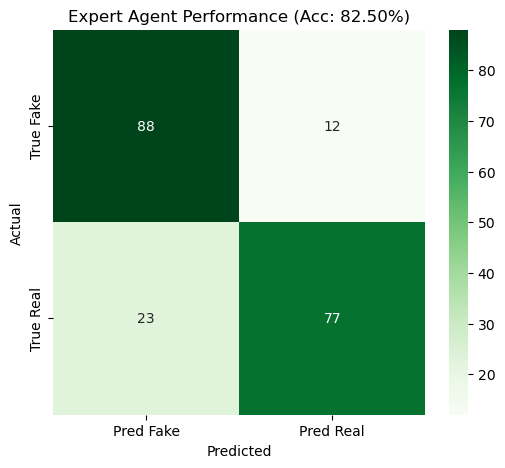

In [25]:
# --- 4. FINAL REPORT ---
print("\n" + "="*40)
print("PHASE 2: EXPERT AGENT RESULTS")
print("="*40)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"YOUR Accuracy: {acc:.2%}")
print(f"Target to Beat: 69.0%")

# Classification Report
print("\nDetailed Report:")
print(classification_report(y_true, y_pred, target_names=['FAKE (0)', 'REAL (1)']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Pred Fake', 'Pred Real'],
            yticklabels=['True Fake', 'True Real'])
plt.title(f"Expert Agent Performance (Acc: {acc:.2%})")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [27]:
print(df_sample.head(10))

                 author                                        clean_title  \
0              Grimhand      make my friends childhood photo into an album   
1      all-top-today_SS                     redditor is fed up with my son   
2              unclegut                                           predator   
3         journeyman369                     this dog looking at a sandwich   
4        DrJasonWoodrue  rhode island official resigns after dressing m...   
5      JadaNeedsaDoggie                      this tower diguised as a tree   
6  TrollXChromosomes_SS  i love friends and family but this one and the...   
7           AmaanSenpai  in my school there is a giant chess board that...   
8              neer21aj     michael collins copy of the apollo flight plan   
9             BlemAsian                                             im sad   

    created_utc               domain  hasImage       id  \
0  1.519767e+09            i.redd.it      True   80qbds   
1  1.478963e+09        